In [1]:
import sys
import os
from pathlib import Path

ABS_PATH = "C:/Users/rosha/Documents/Projects/UWPhotonics/prob_tcn_for_LED"
sys.path.insert(0, str(ABS_PATH))
os.chdir(ABS_PATH)
#base_pth = os.path.abspath(os.path.join(os.path.dirname(Path.cwd())))
base_pth = ABS_PATH
print(base_pth)

import subprocess
import torch
import json
import yaml
import zarr
import matplotlib.pyplot as plt
from modules.utils import save_mem_file
from modules.models import TCN
from modules.grid_search import EncoderDecoderGridSearch
from modules.grid_search.encoder_decoder import ARCH_KEYS
from modules.grid_search.adapters import TCNAdapter
from modules.utils import q88_int_to_hex, q88_hex_to_float, float_to_q88_int, evm_pct, calculate_per_burst_rrmse_pct_loss 
from experiments.test_real_gridsearch import (
    OFDM_CONFIG, ENCODER_DECODER_GRID
)
FILES = ["input_time_series.mem", "encoder_output.mem", "recieved_time.mem", "decoder_output.mem"]

sim_directory = "sv_tcn/tcn6"
DATA_WIDTH = 16
TEST = 20
SAVE_PATH = f"{sim_directory}"
ED_MODEL = "data/experiments/test_real_gridsearch/encoder_decoder_20260911_0905/runs/tcn_ae_6f25ae0d"
CHANNEL_PTH = "data/experiments/test_real_gridsearch/channel_models_20260911_0902/runs/tcn_b338d2dc"

DATA_PATH = "data/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr/sent_burst"
WAVEFORMS = 4
TYPE = "Synthetic"
ed_gs = EncoderDecoderGridSearch(
            ENCODER_DECODER_GRID,
            channel_models=[],
            dataset_path="nothing",
)

def create_plots(data_width, ShowTimeSeries=False, ed_model_pth=ED_MODEL, plot_title="Qx.x"):
    py_freq = []
    with open(os.path.join(base_pth, ed_model_pth, "config.yaml"), "r") as file:
        config = yaml.safe_load(file)
        p = config["params"]
        arch = {k: p[k] for k in ARCH_KEYS}
        encoder = TCN(**arch).to("cpu")
        checkpoint = torch.load(os.path.join(base_pth, ed_model_pth, "model.pt"), map_location="cpu", weights_only=True)
        encoder.load_state_dict(checkpoint["encoder"])
        encoder.eval()

        #ed_gs.preamble = torch.tensor(band_limited_zc_preamble(256, OFDM_CONFIG.subcarrier_spacing*OFDM_CONFIG.baseband_fft_length, float(300000.0), float(7600000.0), 3.0), dtype=torch.float32, device="cpu").unsqueeze(0)
        in_time = create_sent_time()
        #preamble, symbol = in_time[:, :256], in_time[:, 256:]
        py_freq.append(ed_gs._frame_to_freq(in_time, OFDM_CONFIG))


        outp = encoder(in_time)
        
        py_freq.append(ed_gs._frame_to_freq(outp, OFDM_CONFIG))
        recieved_time = send_through_channel(outp)
        py_freq.append(ed_gs._frame_to_freq(recieved_time, OFDM_CONFIG))

        decoder = TCN(**arch).to("cpu")
        decoder.load_state_dict(checkpoint["decoder"])
        decoder.eval()

        decoded_time = decoder(recieved_time)
        #decoded_time = _decode_freq(encoder.eval(), decoder.eval(), channel_model, eval_sent_time, ofdm_config)
        
        py_freq.append(ed_gs._frame_to_freq(decoded_time, OFDM_CONFIG))

        #print(f"input av power: {torch.square(torch.mean(in_time))}")
        #print(f"encoded av power: {torch.square(torch.mean(outp))}")
        #print(f"recieved av power: {torch.square(torch.mean(recieved_time))}")
        #print(f"decoded av power: {torch.square(torch.mean(decoded_time))}")

        #print(f"encoded average: {torch.mean(outp)}")
        #print(f"encoded max: {torch.max(outp)}")
        #print(f"encoded min: {torch.min(outp)}")
        #print(f"decoded average: {torch.mean(decoded_time)}")
        #print(f"decoded max: {torch.max(decoded_time)}")
        #print(f"decoded min: {torch.min(decoded_time)}\n")
    
    all_time_series = []
    for file in FILES:
          with open(os.path.join(base_pth, SAVE_PATH, file), "r") as file:
                time = []
                for line in file:
                    line = line.strip()
                    if line[0:2] != "//":
                        num = q88_hex_to_float(line, data_width)
                        time.append(num)
                all_time_series.append(time)

    time_tensors = [torch.tensor(all_time_series[0]).view(WAVEFORMS, 940),  torch.tensor(all_time_series[1]).view(WAVEFORMS, 940),  torch.tensor(all_time_series[2]).view(WAVEFORMS, 940), torch.tensor(all_time_series[3]).view(WAVEFORMS, 940)]

    freq_tensors = [ed_gs._frame_to_freq(time_tensors[0], OFDM_CONFIG), ed_gs._frame_to_freq(time_tensors[1], OFDM_CONFIG), ed_gs._frame_to_freq(time_tensors[2], OFDM_CONFIG), ed_gs._frame_to_freq(time_tensors[3], OFDM_CONFIG)]
    
    evm_sv = evm_pct(freq_tensors[0], freq_tensors[3]).item()
    rrmse = calculate_per_burst_rrmse_pct_loss(freq_tensors[0], freq_tensors[3])
    print("SystemVerilog TCN Performance Metrics:")
    print(f"EVM: {evm_sv}")
    print(f"RRMSE: {rrmse}\n")

    evm_py = evm_pct(py_freq[0], py_freq[3]).item()
    rrmse = calculate_per_burst_rrmse_pct_loss(py_freq[0], py_freq[3])
    print("Pytorch TCN Performance Metrics:")
    print(f"EVM: {evm_py}")
    print(f"RRMSE: {rrmse}")

    fig = ed_gs._plot_constellation_enhanced_for_sv(run_dir=Path(os.path.join(base_pth, SAVE_PATH)), sv=freq_tensors, py=py_freq, freqs=OFDM_CONFIG.subcarrier_freqs_hz, evm_sv=evm_sv, evm_py=evm_py, channel_type=plot_title)
    
    if ShowTimeSeries:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

        ax1.plot(all_time_series[1][0:(940 * WAVEFORMS)], label="SystemVerilog", marker='o')
        ax1.plot(list(outp.detach().numpy().flatten())[0:(940 * WAVEFORMS)], label="Pytorch", marker='s')
        ax1.plot(list(in_time.detach().numpy().flatten())[0:(940 * WAVEFORMS)], label="input", marker='s')
        #ax1.set_xlabel("Time Series")
        ax1.set_ylabel("Output")
        ax1.set_title("Plotting Input and encoded")
        ax1.legend()

        ax2.plot(all_time_series[3][0:(940 * WAVEFORMS)], label="SystemVerilog", marker='o')
        ax2.plot(list(decoded_time.detach().numpy().flatten())[0:(940 * WAVEFORMS)], label="Pytorch", marker='s')
        ax2.plot(list(recieved_time.detach().numpy().flatten())[0:(940 * WAVEFORMS)], label="input", marker='s')
        ax2.set_xlabel("Time Series")
        ax2.set_ylabel("Output")
        ax2.set_title("Plotting Recived and Decoded")
        ax2.legend()

        plt.tight_layout()
        plt.show()

def read_dataset(path, n_frames: int = 64) -> torch.Tensor:
    sent_arr = zarr.open(path, mode='r')
    sent_symbols = torch.from_numpy(sent_arr[:n_frames, :]).float()
    return sent_symbols

def create_sent_time():
    if TYPE == "Synthetic":
        return ed_gs._sample_batch(WAVEFORMS, len(OFDM_CONFIG.active_carrier_indices)*2, OFDM_CONFIG, "please add the preamble")[1]
    elif TYPE == "Real":
        return read_dataset(os.path.join(base_pth, DATA_PATH), n_frames=WAVEFORMS)
    elif TYPE == "Step":
        length = 940
        # 4 cycles (Frequency x4)
        single_waveform = (((torch.arange(length) * 2 * 1) // length) % 2 * 2.0 - 1.0).to(torch.float32)
        return single_waveform.repeat(WAVEFORMS, 1)
    elif TYPE == "Random Step":
        length = 940
        values = torch.tensor([0.0, 1.0, -1.0, 2.0, -3.0, 3.0], dtype=torch.float32)
        time_series = torch.empty((WAVEFORMS, length), dtype=torch.float32)

        for burst_idx in range(WAVEFORMS):
            position = 0
            while position < length:
                remaining = length - position
                min_step = min(80, remaining)
                max_step = min(300, remaining)
                step_length = int(torch.randint(min_step, max_step + 1, ()).item())
                value = values[torch.randint(0, len(values), ())].item()
                time_series[burst_idx, position:position + step_length] = value
                position += step_length

        return time_series
    else:
        raise ValueError("TYPE was not correctly specified.")

def writeSentTime(save_pth, datawidth):
    sent_time= create_sent_time()
    time_series = []
    tensor_time_series = sent_time.detach().cpu().numpy()
    for burst in tensor_time_series:    
            for point in burst:
                time_series.append(q88_int_to_hex(float_to_q88_int(point, data_width=datawidth), data_width=datawidth))
    save_mem_file(os.path.join(base_pth, save_pth, "input_time_series.mem"), time_series, "OFDM modulated time series - includes cyclic prefix and preamble")

def read_model(read_pth, save_pth, datawidth):
    output_dir = os.path.join(base_pth, save_pth)
    os.makedirs(output_dir, exist_ok=True)
    model = torch.load(os.path.join(base_pth, read_pth), weights_only=True)

    for type in ["encoder", "decoder"]:
        e_or_d = model[type]
        keys = e_or_d.keys()
        #print(f"{type} keys: {keys}")
        for key in keys:
            #print(f"Keyname: {key}")

            tensor = e_or_d[key]
            for i, hidden_channel in enumerate(tensor):
                #print(f"    Channel{i}:")
                #print(hidden_channel)

                arr = hidden_channel.detach().cpu().numpy().flatten()
                save_arr = []
                for num in arr:
                    hexa = q88_int_to_hex(float_to_q88_int(num, datawidth), datawidth)
                    #print(f"        Weight/Bias: {num} Hex: {hexa}")
                    save_arr.append(hexa)

                safe_key = key.replace('.', '_')
                save_mem_file(os.path.join(output_dir, f"{type}", safe_key, f"channel{i}.mem"), save_arr, f"contains {len(arr)} values", printDebug=False)

def send_through_channel(sent_time):
    with open(os.path.join(base_pth, CHANNEL_PTH, "config.yaml"), "r") as file:
            config = yaml.safe_load(file)
            params = config["params"]
            #print(f"Model config: {params}")
            adapter = TCNAdapter.load(params=params, checkpoint=os.path.join(base_pth, CHANNEL_PTH, "model.pt"), device="cpu")
            rec_time_tensor = adapter.model(sent_time)
            #print(rec_time_tensor)
            return rec_time_tensor[0] # 0 for noise, 1 for mean

def Execute_Channel(data_width, Channel_pth, Save_pth):
    with open(os.path.join(base_pth, Channel_pth, "config.yaml"), "r") as file:
        sent_time = [[]]
        with open(os.path.join(base_pth, Save_pth, "encoder_output.mem"), "r") as file:
            for line in file:
                line = line.strip()
                if line[0:2] != "//":
                    num = q88_hex_to_float(line, data_width)
                    sent_time[0].append(num)
        recieved_time = send_through_channel(torch.tensor(sent_time)).detach().cpu().numpy().flatten()
        words = []
        for sample in recieved_time:
            words.append(q88_int_to_hex(float_to_q88_int(sample, data_width), data_width))
        save_mem_file(os.path.join(base_pth, Save_pth, "recieved_time.mem"), words, f"Sent through the channel model")

C:/Users/rosha/Documents/Projects/UWPhotonics/prob_tcn_for_LED


In [2]:
writeSentTime(SAVE_PATH, DATA_WIDTH)

  Saved 3760 values → C:/Users/rosha/Documents/Projects/UWPhotonics/prob_tcn_for_LED\sv_tcn/tcn6\input_time_series.mem


In [3]:
read_model(os.path.join(base_pth, ED_MODEL, "model.pt"), os.path.join(base_pth, SAVE_PATH, "TestingData", f"Test{TEST}"), DATA_WIDTH)

In [4]:
print("Running encoder...")
result = subprocess.run(
    ["iverilog", "-g2012", "-P", f'tb.MODEL_TYPE="encoder"', "-P", f"tb.TEST={TEST}", "-P", f"tb.DATA_WIDTH={DATA_WIDTH}", "-P", f"tb.SAMPLES={940 * WAVEFORMS}", "-o", "tb.vvp", "tb.sv"],
    cwd=sim_directory,
    capture_output=True,
    text=True,
    check=True,
)
result2 = subprocess.run(
    ["vvp", "tb.vvp"],
    cwd=sim_directory,
    capture_output=True,
    text=True,
    check=True,
)
print(result2.stdout)

Running encoder...
Network Latency: 49
DATAWIDTH: 16, MODELTYPE:encoder, TEST:20
Not generating a waveform viewer because time units exceed 26634, at 23060 time units.
tb.sv:85: $finish called at 23076 (1s)



In [5]:
Execute_Channel(DATA_WIDTH, CHANNEL_PTH, SAVE_PATH)

  Saved 3760 values → C:/Users/rosha/Documents/Projects/UWPhotonics/prob_tcn_for_LED\sv_tcn/tcn6\recieved_time.mem


In [6]:
print("Running decoder...")
result3 = subprocess.run(
    ["iverilog", "-g2012", "-P", f'tb.MODEL_TYPE="decoder"', "-P", f"tb.TEST={TEST}", "-P", f"tb.DATA_WIDTH={DATA_WIDTH}", "-P", f"tb.SAMPLES={940 * WAVEFORMS}", "-o", "tb.vvp", "tb.sv"],
    cwd=sim_directory,
    capture_output=True,
    text=True,
    check=True,
)
result4 = subprocess.run(
    ["vvp", "tb.vvp"],
    cwd=sim_directory,
    capture_output=True,
    text=True,
    check=True,
)
print(result4.stdout)

Running decoder...
Network Latency: 49
DATAWIDTH: 16, MODELTYPE:decoder, TEST:20
Not generating a waveform viewer because time units exceed 26634, at 23060 time units.
tb.sv:85: $finish called at 23076 (1s)



SystemVerilog TCN Performance Metrics:
EVM: 12.46119213104248
RRMSE: 12.452066421508789

Pytorch TCN Performance Metrics:
EVM: 12.281586647033691
RRMSE: 12.261512756347656


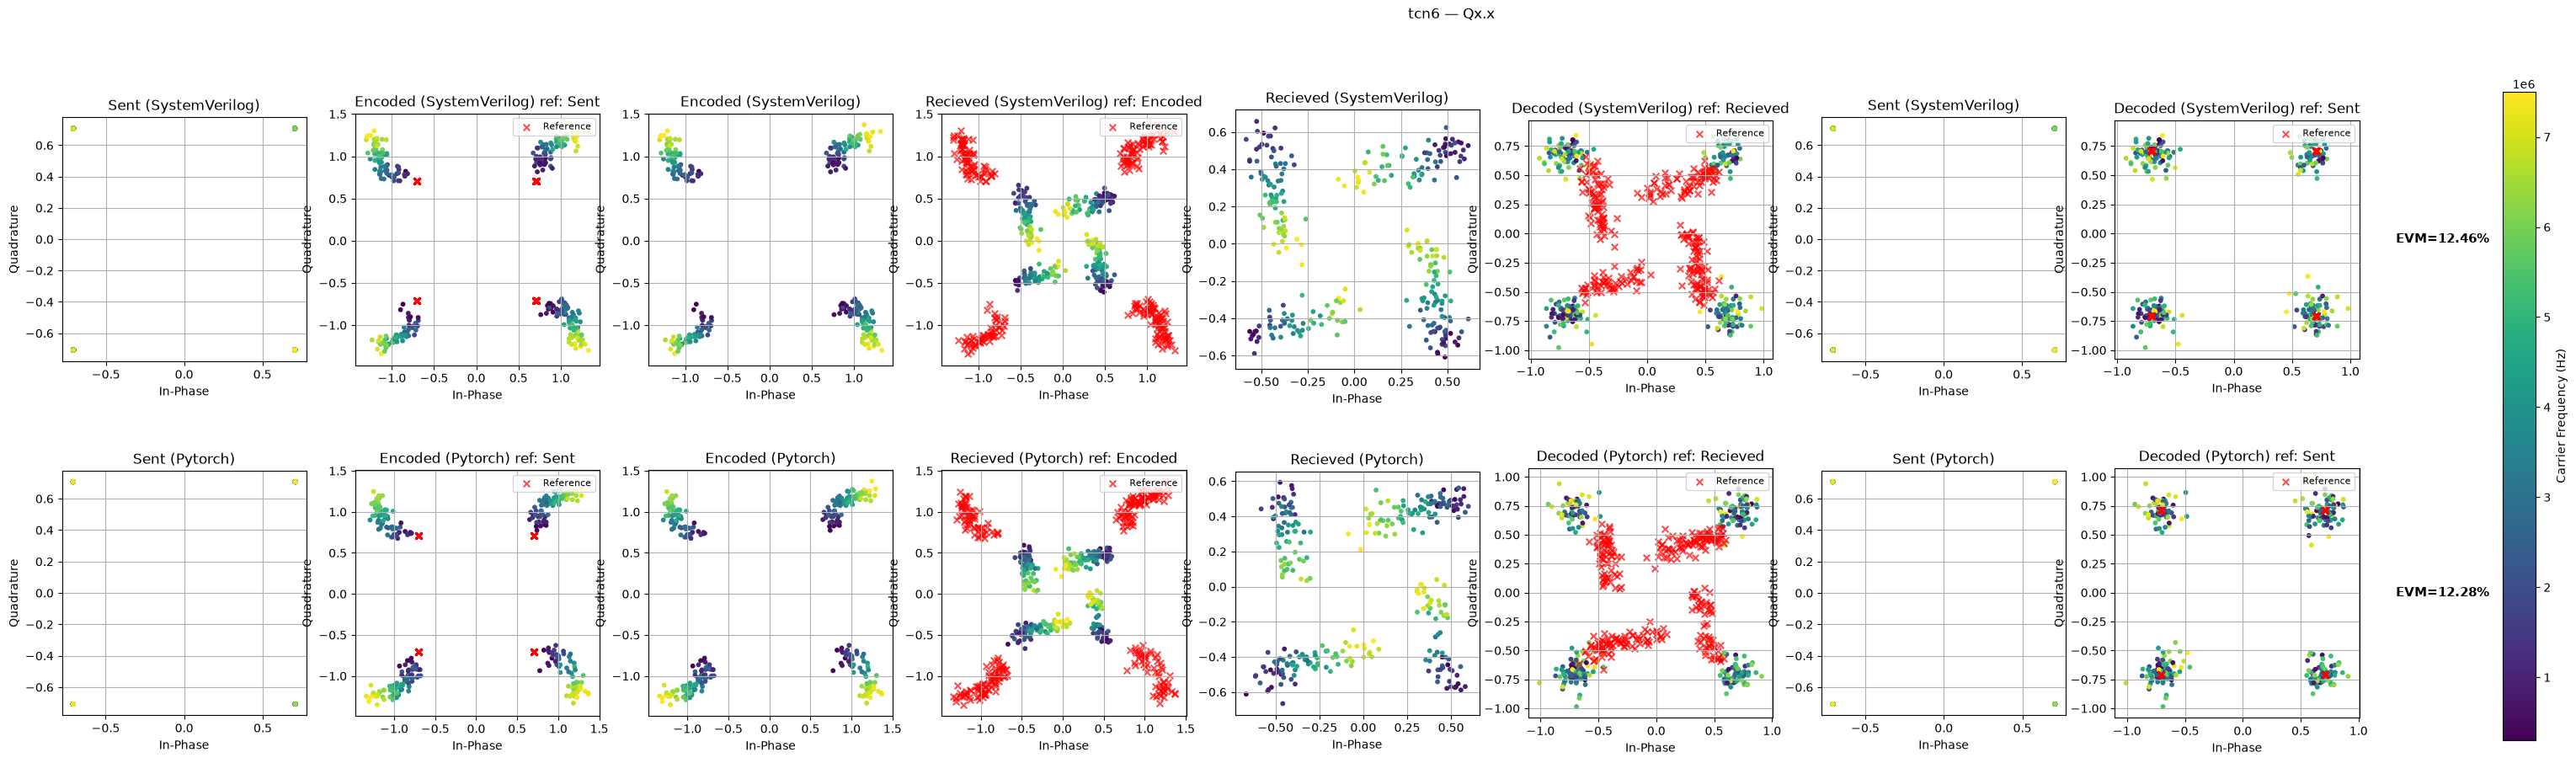

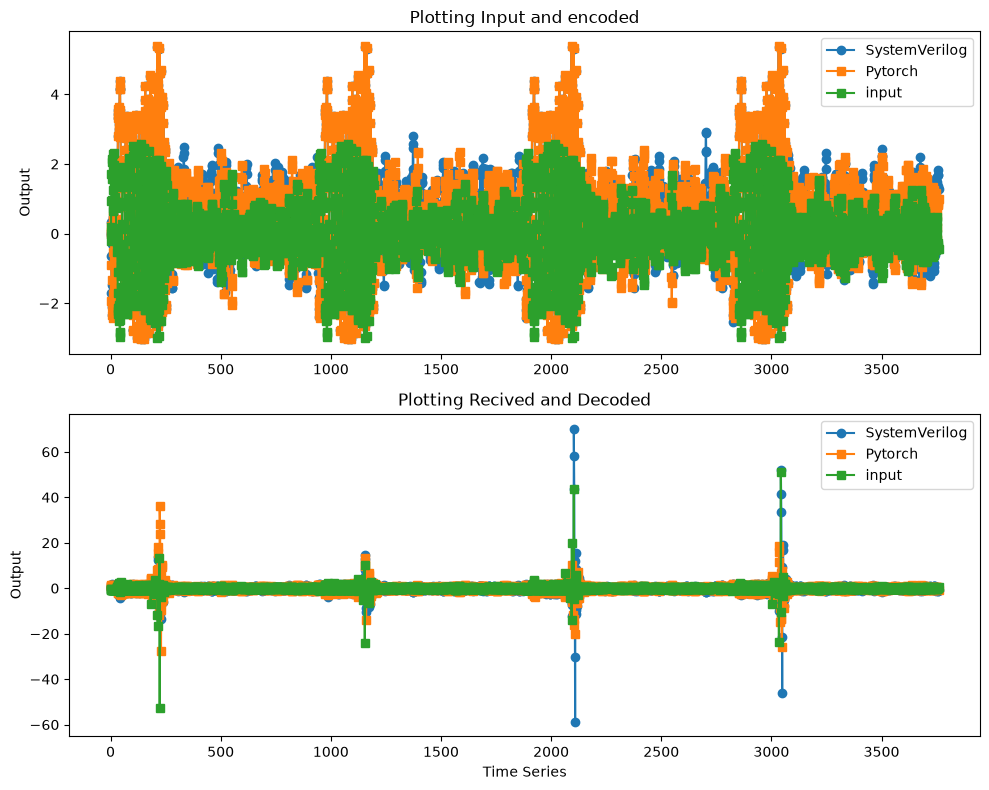

In [7]:
plt.ion()
create_plots(DATA_WIDTH, ShowTimeSeries=True, ed_model_pth=os.path.join(base_pth, ED_MODEL))